### Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
import yaml
import os

warnings.filterwarnings('ignore')

### Step 1: Load Data and Models

In [ ]:
from model import load_engineered_splits

data = load_engineered_splits()

X_train_cls = data["cls"]["X_train_cls"]
X_test_cls = data["cls"]["X_test_cls"]
X_val_cls = data["cls"]["X_val_cls"]
y_train_cls = data["cls"]["y_train_cls"]
y_test_cls = data["cls"]["y_test_cls"]
y_val_cls = data["cls"]["y_val_cls"]

X_train_reg = data["reg"]["X_train_reg"]
X_test_reg = data["reg"]["X_test_reg"]
X_val_reg = data["reg"]["X_val_reg"]
y_train_cls = data["cls"]["y_train_cls"]
y_train_reg = data["reg"]["y_train_reg"]
y_test_reg = data["reg"]["y_test_reg"]
y_val_reg = data["reg"]["y_val_reg"]

print("All data loaded...")

    All engineered splits loaded
   Classification train: (27577, 23)
   Regression train:     (24943, 16)
All data loaded...


In [ ]:
from model import load_all_models

models = load_all_models()

cls_LogisticRegression     = models['cls']["LogisticRegression"]
cls_RandomForest     = models['cls']["RandomForest"]
cls_XGBoost    = models['cls']["XGBoost"]
cls_LightGBM     = models['cls']["LightGBM"]

reg_LinearRegression    = models['reg']["LinearRegression"]
reg_RandomForest    = models['reg']["RandomForest"]
reg_XGBoost    = models['reg']["XGBoost"]
reg_LightGBM    = models['reg']["LightGBM"]

cluster_KMeans = models["cluster"]["KMeans"]
cluster_GMM = models["cluster"]["GMM"]


print("Models loaded")




--- Loading all models ---
 Loaded cls_LogisticRegression.joblib
 Loaded cls_RandomForest.joblib
 Loaded cls_XGBoost.joblib
 Loaded cls_LightGBM.joblib
 Loaded reg_LinearRegression.joblib
 Loaded reg_RandomForest.joblib
 Loaded reg_XGBoost.joblib
 Loaded reg_LightGBM.joblib
 Loaded cluster_KMeans.joblib
 Loaded cluster_GMM.joblib
Models loaded


###  Step 2: Feature Importance Plot — Classification

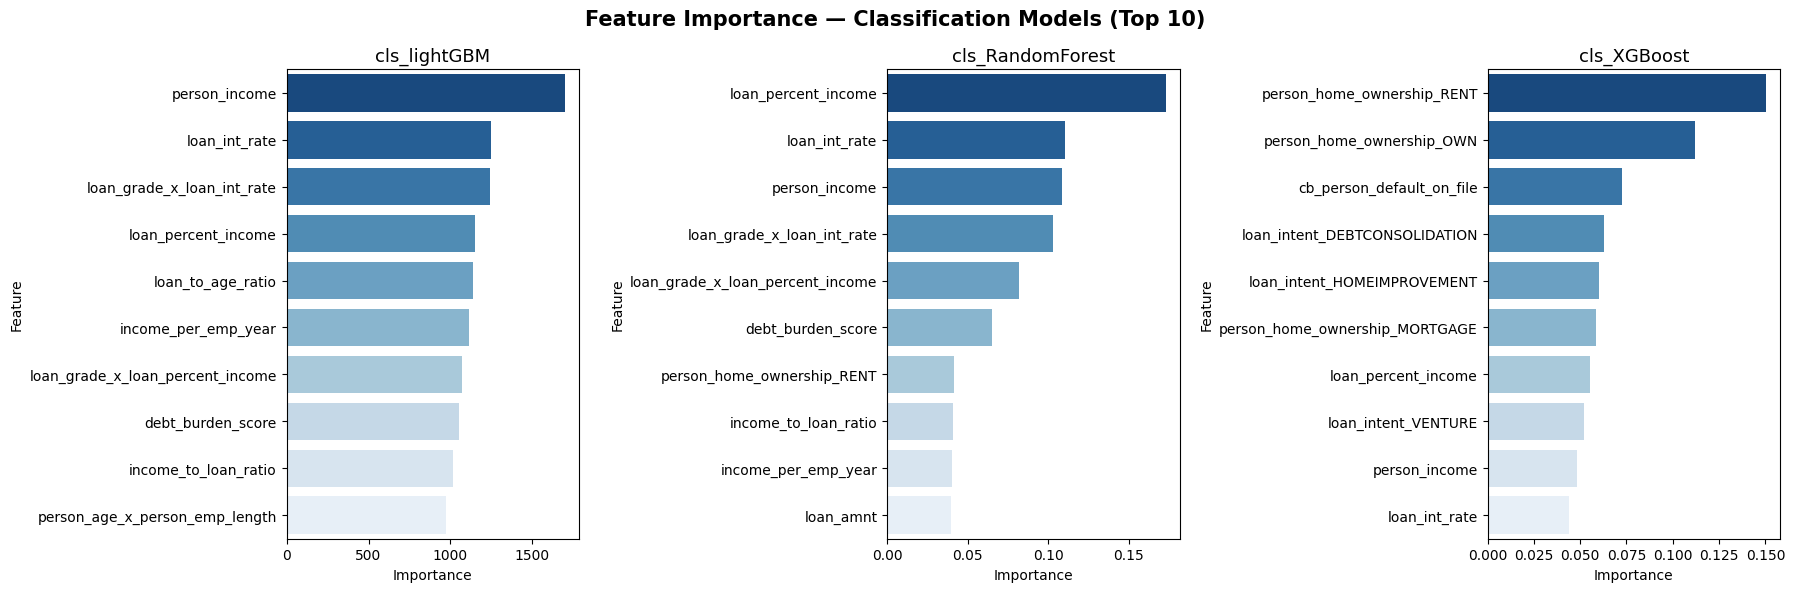

In [ ]:
# Best cls models only

cls_models = {
    "cls_lightGBM":cls_LightGBM,
    "cls_LogisticRegression":cls_LogisticRegression,
    "cls_RandomForest":cls_RandomForest,
    "cls_XGBoost":cls_XGBoost
}

tree_cls_models = {
    k: v for k, v in cls_models.items()
    if k != 'cls_LogisticRegression'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.ravel()

for idx, (name, model) in enumerate(tree_cls_models.items()):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train_cls.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(10)

    sns.barplot(x=feat_imp.values, y=feat_imp.index,
                ax=axes[idx], palette='Blues_r')
    axes[idx].set_title(f'{name}', fontsize=13)
    axes[idx].set_xlabel('Importance')
    axes[idx].set_ylabel('Feature')

plt.suptitle('Feature Importance — Classification Models (Top 10)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: SHAP Summary Plot — Classification


Why sample 1000:

SHAP is computationally expensive on full dataset
1000 samples is enough for reliable global explanation

In [ ]:
# Use best model — LightGBM
# Use sample of training data for speed

SHAP_SAMPLE = 1000

X_shap_cls = X_train_cls.sample(
    n=SHAP_SAMPLE, random_state=42).reset_index(drop=True)

print(f"SHAP sample shape: {X_shap_cls.shape}")

# Create SHAP explainer
explainer_cls = shap.TreeExplainer(cls_models['cls_lightGBM'])

# Calculate SHAP values
print("Calculating SHAP values...")
shap_values_cls = explainer_cls.shap_values(X_shap_cls)

print(f"SHAP values type  : {type(shap_values_cls)}")
print(f"SHAP values shape : {np.array(shap_values_cls).shape}")
print("SHAP values calculated")

SHAP sample shape: (1000, 23)
Calculating SHAP values...
SHAP values type  : <class 'list'>
SHAP values shape : (2, 1000, 23)
SHAP values calculated


In [ ]:
'''Plot        What it shows
Bar plot    Mean absolute SHAP — overall importance
Beeswarm    Direction — red = high value increases default risk'''

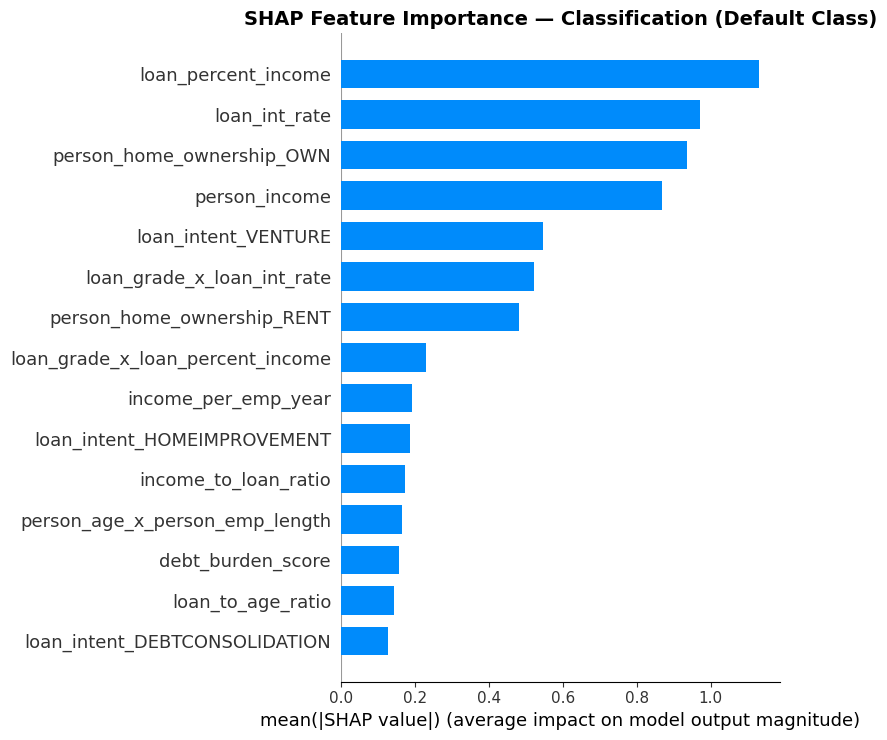

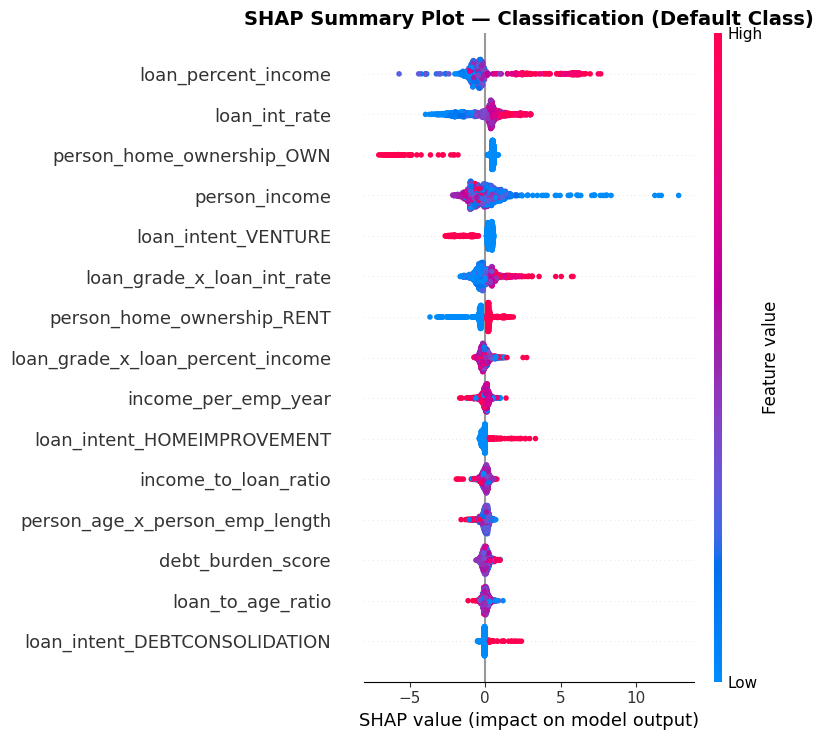

In [8]:
# SHAP values for Default class (index 1)
shap_values_cls_default = shap_values_cls[1]

# Plot 1 — Bar plot (mean absolute SHAP)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_cls_default,
    X_shap_cls,
    plot_type='bar',
    max_display=15,
    show=False)
plt.title('SHAP Feature Importance — Classification (Default Class)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2 — Beeswarm plot (direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_cls_default,
    X_shap_cls,
    plot_type='dot',
    max_display=15,
    show=False)
plt.title('SHAP Summary Plot — Classification (Default Class)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 4: SHAP Waterfall Plot — Classification

Non-Default sample idx : 1 (prob=0.0567)
Default sample idx     : 11 (prob=0.9802)
Borderline sample idx  : 695 (prob=0.6051)

Expected value (base rate) : -2.1107


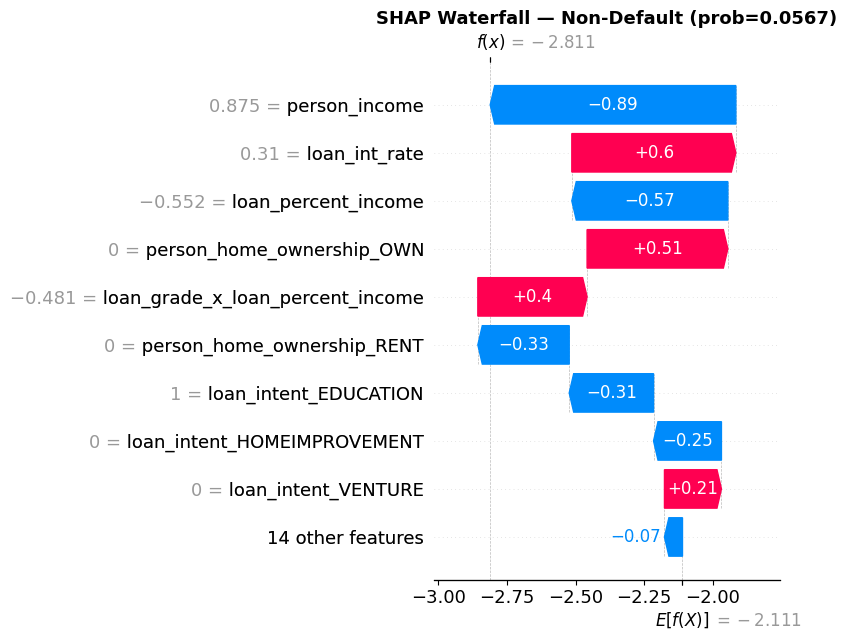

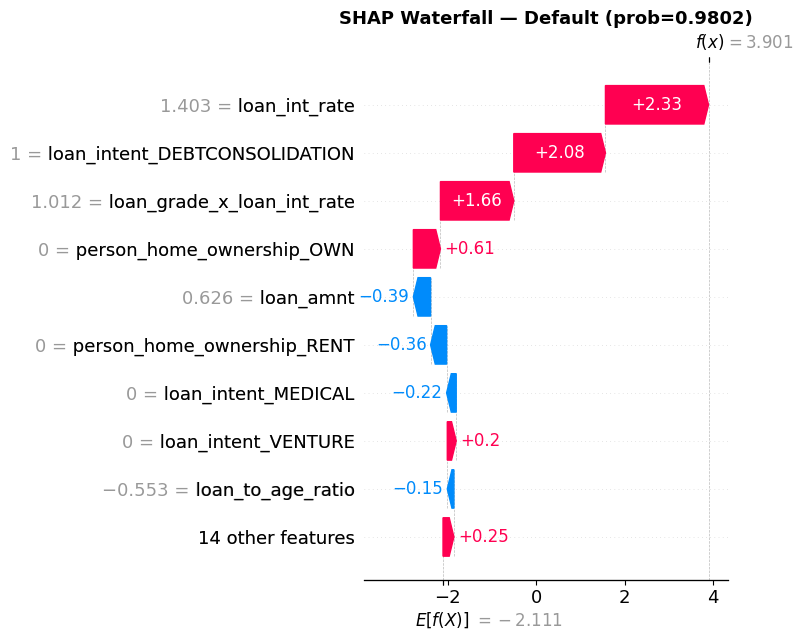

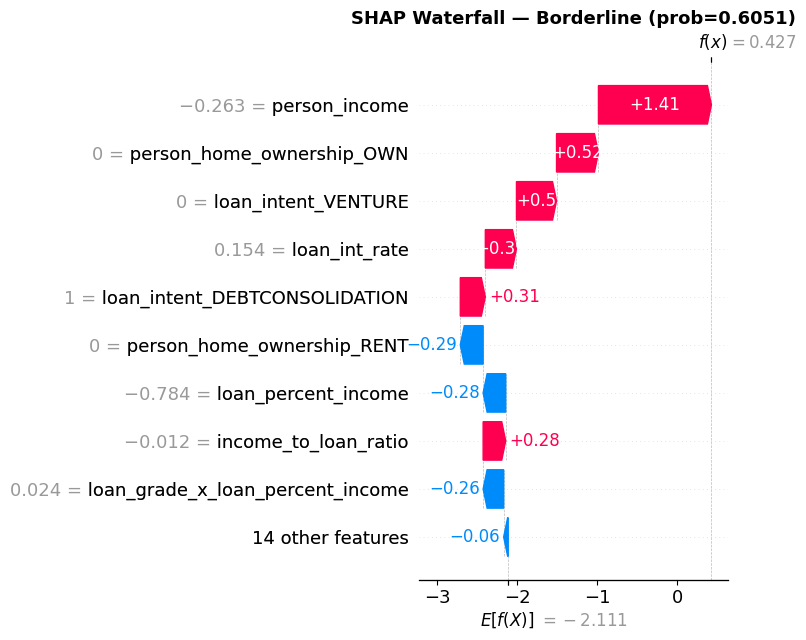

In [ ]:
BEST_THRESHOLD_CLS = 0.6

y_prob_val = cls_models['cls_lightGBM'].predict_proba(X_val_cls)[:, 1]
y_pred_val = (y_prob_val >= BEST_THRESHOLD_CLS).astype(int)

# Fix — convert to numpy
y_val_cls_np = y_val_cls.values.ravel()

# Find sample indices
idx_non_default = np.where((y_pred_val == 0) & (y_val_cls_np == 0))[0][0]
idx_default     = np.where((y_pred_val == 1) & (y_val_cls_np == 1))[0][0]
idx_borderline  = np.argmin(np.abs(y_prob_val - BEST_THRESHOLD_CLS))

print(f"Non-Default sample idx : {idx_non_default} "
      f"(prob={y_prob_val[idx_non_default]:.4f})")
print(f"Default sample idx     : {idx_default} "
      f"(prob={y_prob_val[idx_default]:.4f})")
print(f"Borderline sample idx  : {idx_borderline} "
      f"(prob={y_prob_val[idx_borderline]:.4f})")

# Create SHAP explainer on val set
explainer_val   = shap.TreeExplainer(cls_models['cls_lightGBM'])
shap_values_val = explainer_val.shap_values(X_val_cls)
shap_values_val_default = shap_values_val[1]
expected_value  = explainer_val.expected_value[1]

print(f"\nExpected value (base rate) : {expected_value:.4f}")

# Plot waterfall for each sample
for label, idx in [('Non-Default', idx_non_default),
                   ('Default',     idx_default),
                   ('Borderline',  idx_borderline)]:

    shap_explanation = shap.Explanation(
        values        = shap_values_val_default[idx],
        base_values   = expected_value,
        data          = X_val_cls.iloc[idx].values,
        feature_names = X_val_cls.columns.tolist())

    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(shap_explanation, show=False)
    plt.title(
        f'SHAP Waterfall — {label} '
        f'(prob={y_prob_val[idx]:.4f})',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Step 5: Calibration Curve — Classification 

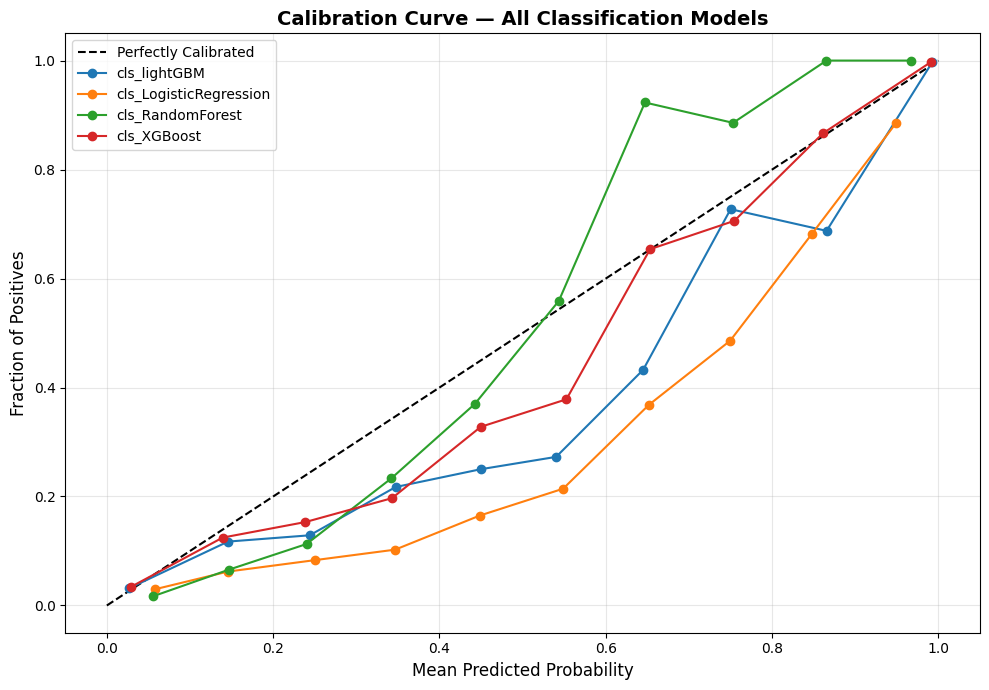

In [10]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 7))

# Perfect calibration line
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

for name, model in cls_models.items():
    y_prob = model.predict_proba(X_val_cls)[:, 1]
    
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_val_cls, y_prob, n_bins=10)
    
    plt.plot(mean_predicted_value,
             fraction_of_positives,
             marker='o', label=f'{name}')

plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curve — All Classification Models',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 6: Feature Importance — Regression

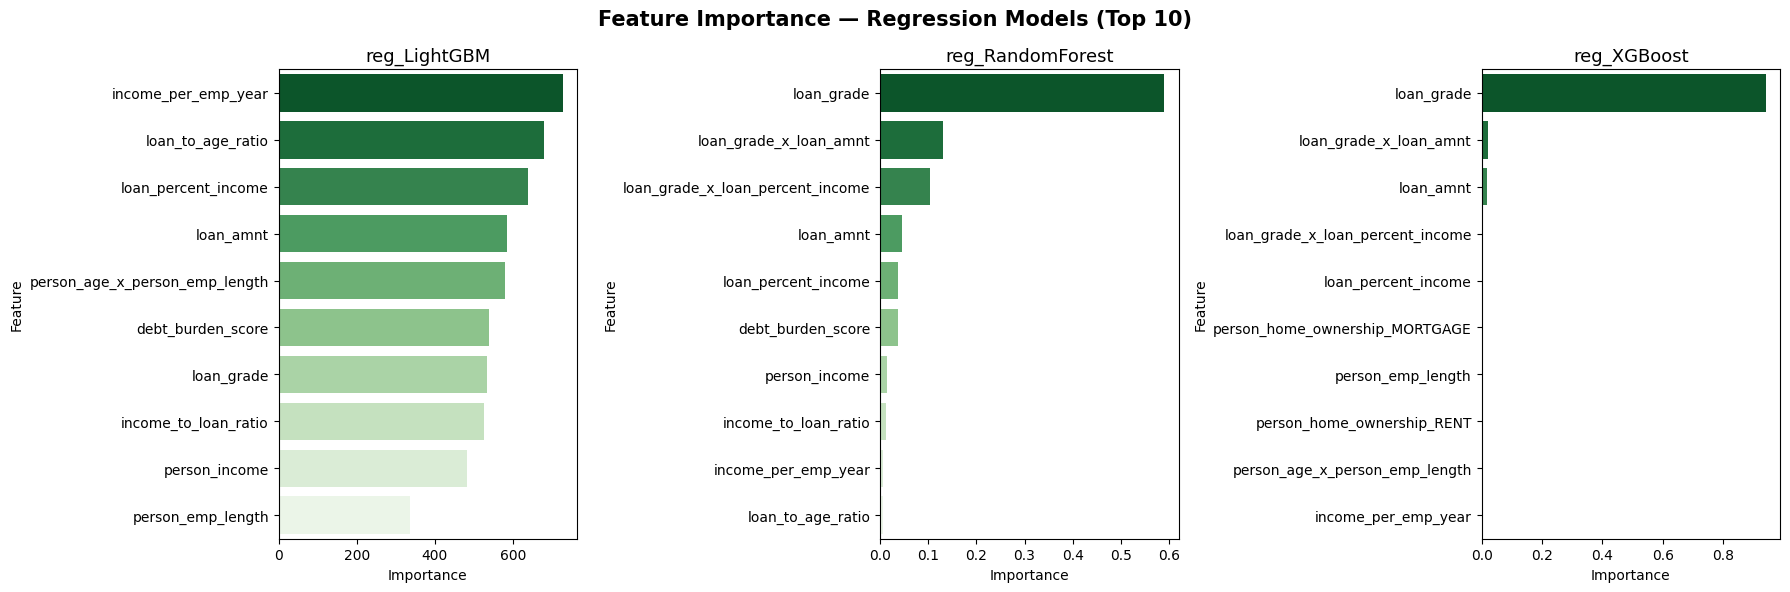

In [11]:
reg_models = {
    "reg_LightGBM":reg_LightGBM,
    "reg_LinearRegression":reg_LinearRegression,
    "reg_RandomForest":reg_RandomForest,
    "reg_XGBoost":reg_XGBoost
}
# Skip LinearRegression — no feature_importances_

tree_reg_models = {
    k: v for k, v in reg_models.items()
    if k != 'reg_LinearRegression'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.ravel()

for idx, (name, model) in enumerate(tree_reg_models.items()):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train_reg.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(10)

    sns.barplot(x=feat_imp.values, y=feat_imp.index,
                ax=axes[idx], palette='Greens_r')
    axes[idx].set_title(f'{name}', fontsize=13)
    axes[idx].set_xlabel('Importance')
    axes[idx].set_ylabel('Feature')

plt.suptitle('Feature Importance — Regression Models (Top 10)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 7: SHAP Summary Plot — Regression

SHAP sample shape: (1000, 16)
Calculating SHAP values...
SHAP values shape : (1000, 16)
SHAP values calculated


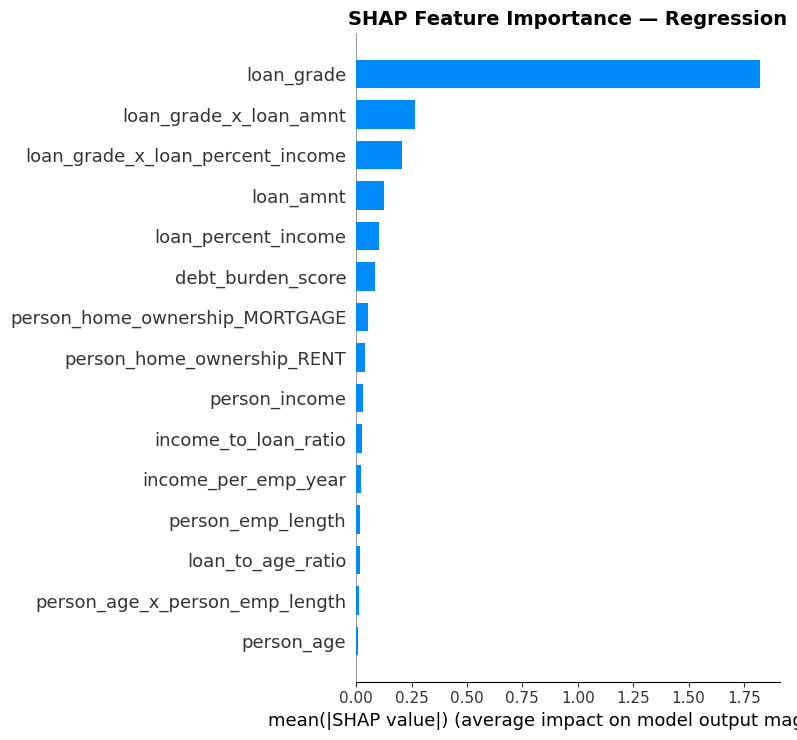

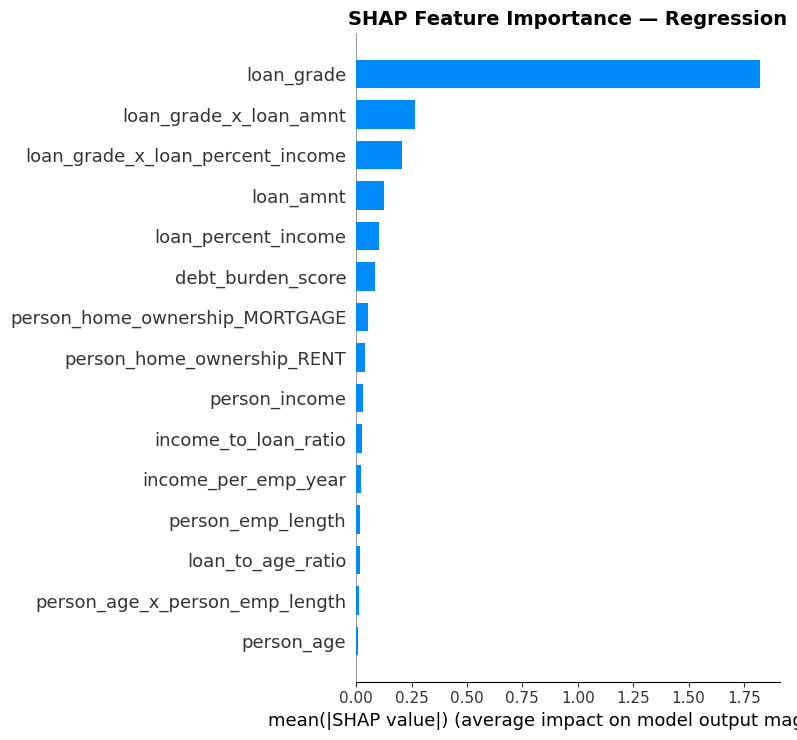

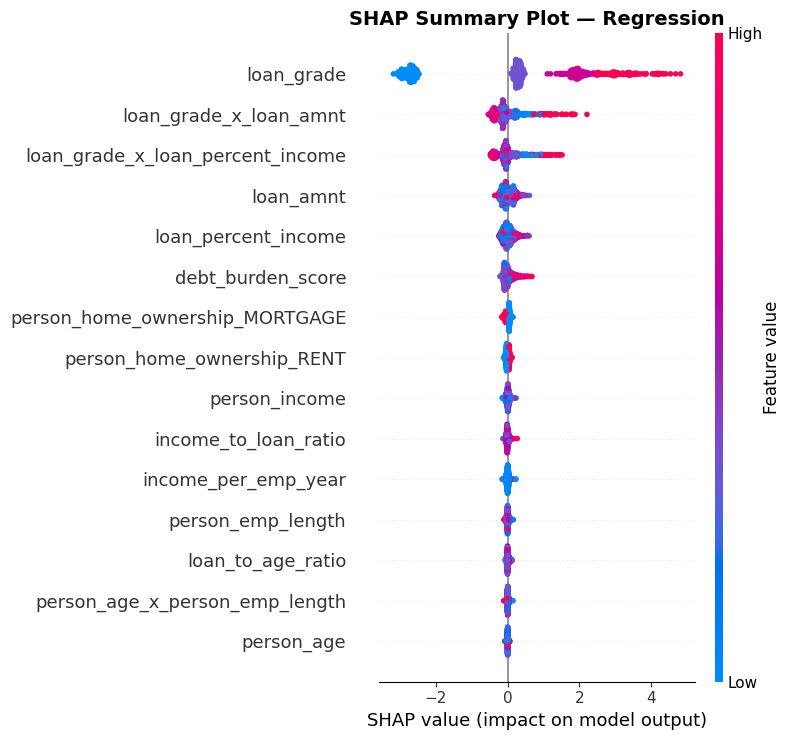

In [13]:
# Use best regression model — RandomForest
# Sample for speed

X_shap_reg = X_train_reg.sample(
    n=1000, random_state=42).reset_index(drop=True)

print(f"SHAP sample shape: {X_shap_reg.shape}")

# Create SHAP explainer
explainer_reg = shap.TreeExplainer(
    reg_models['reg_RandomForest'])

# Calculate SHAP values
print("Calculating SHAP values...")
shap_values_reg = explainer_reg.shap_values(X_shap_reg)

print(f"SHAP values shape : {np.array(shap_values_reg).shape}")
print("SHAP values calculated")

# Plot 1 — Bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_reg,
    X_shap_reg,
    plot_type='bar',
    max_display=15,
    show=False)
plt.title('SHAP Feature Importance — Regression',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2 — Beeswarm plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_reg,
    X_shap_reg,
    plot_type='dot',
    max_display=15,
    show=False)
plt.title('SHAP Summary Plot — Regression',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 8: SHAP Waterfall — Regression

Low rate  idx : 2086  (pred=6.6467)
High rate idx : 935 (pred=19.4053)
Mid rate  idx : 410  (pred=11.1010)
[11.00783999]


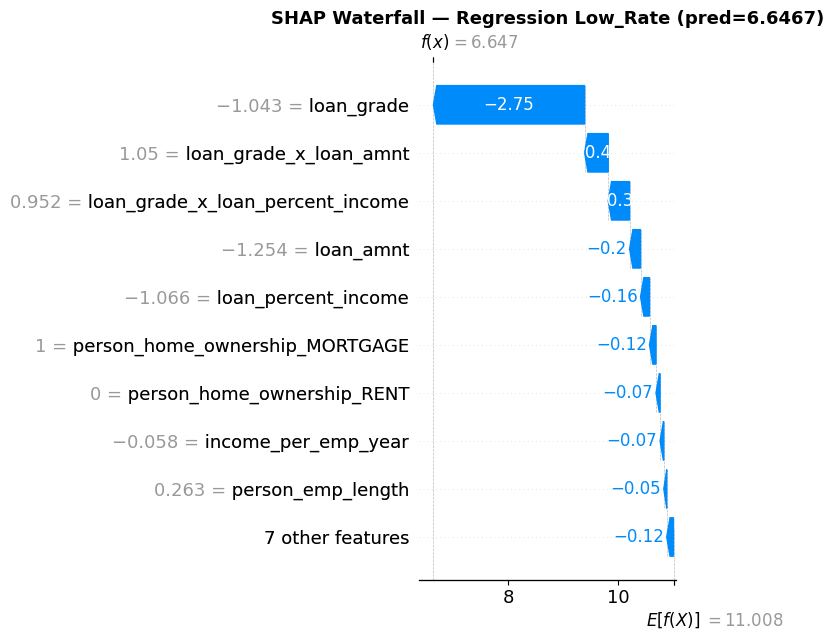

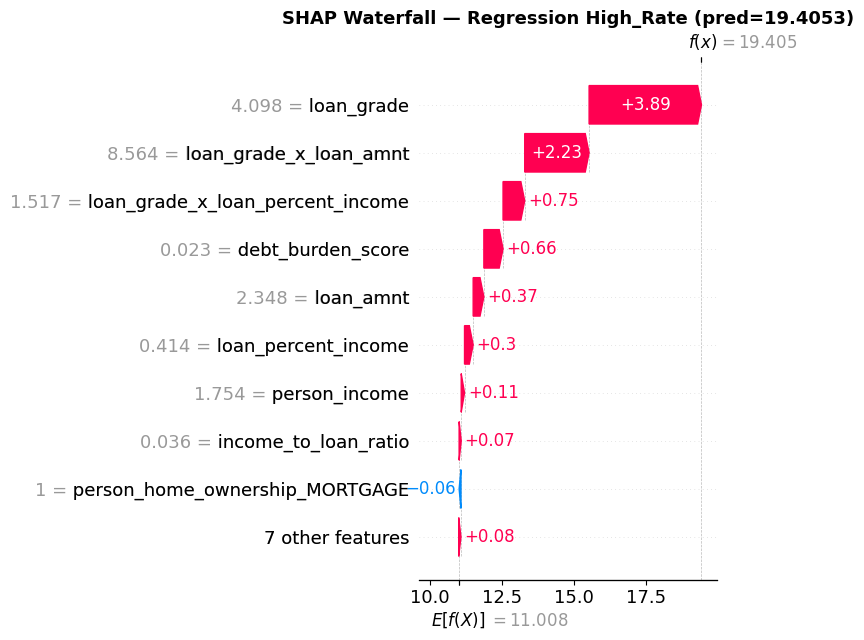

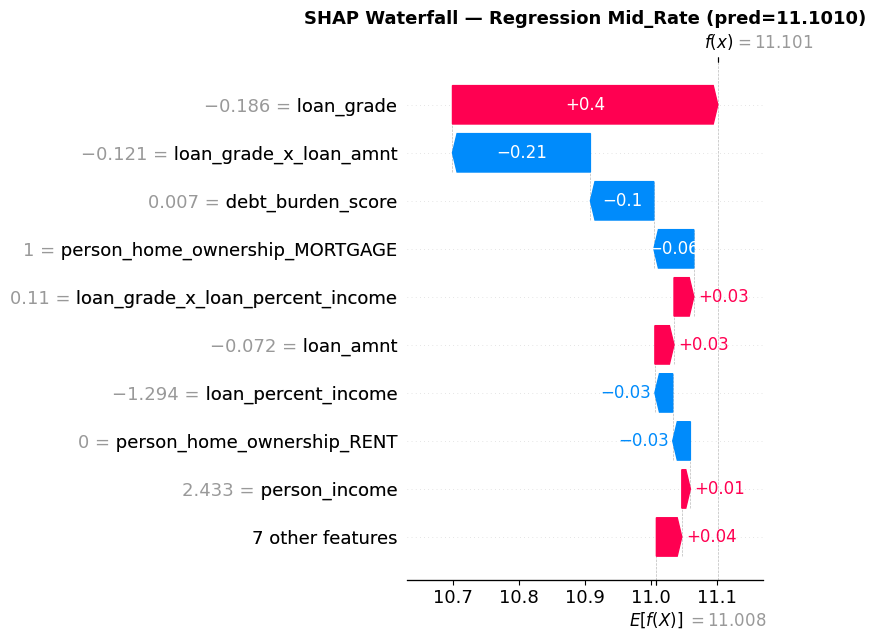

In [15]:
# Pick 3 samples — low, high and mid interest rate predictions
y_pred_reg_val = reg_models['reg_RandomForest'].predict(X_val_reg)

idx_low_rate  = np.argmin(y_pred_reg_val)
idx_high_rate = np.argmax(y_pred_reg_val)
idx_mid_rate  = np.argmin(
    np.abs(y_pred_reg_val - y_pred_reg_val.mean()))

print(f"Low rate  idx : {idx_low_rate}  "
      f"(pred={y_pred_reg_val[idx_low_rate]:.4f})")
print(f"High rate idx : {idx_high_rate} "
      f"(pred={y_pred_reg_val[idx_high_rate]:.4f})")
print(f"Mid rate  idx : {idx_mid_rate}  "
      f"(pred={y_pred_reg_val[idx_mid_rate]:.4f})")

# SHAP explainer on val set
explainer_reg_val  = shap.TreeExplainer(
    reg_models['reg_RandomForest'])
shap_values_reg_val = explainer_reg_val.shap_values(X_val_reg)
expected_value_reg  = explainer_reg_val.expected_value

print(expected_value_reg)

# Plot waterfall for each sample
for label, idx in [('Low_Rate',  idx_low_rate),
                   ('High_Rate', idx_high_rate),
                   ('Mid_Rate',  idx_mid_rate)]:

    shap_explanation = shap.Explanation(
        values        = shap_values_reg_val[idx],
        base_values   = expected_value_reg,
        data          = X_val_reg.iloc[idx].values,
        feature_names = X_val_reg.columns.tolist())

    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(shap_explanation, show=False)
    plt.title(
        f'SHAP Waterfall — Regression {label} '
        f'(pred={y_pred_reg_val[idx]:.4f})',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Step 9: Cluster Radar Chart

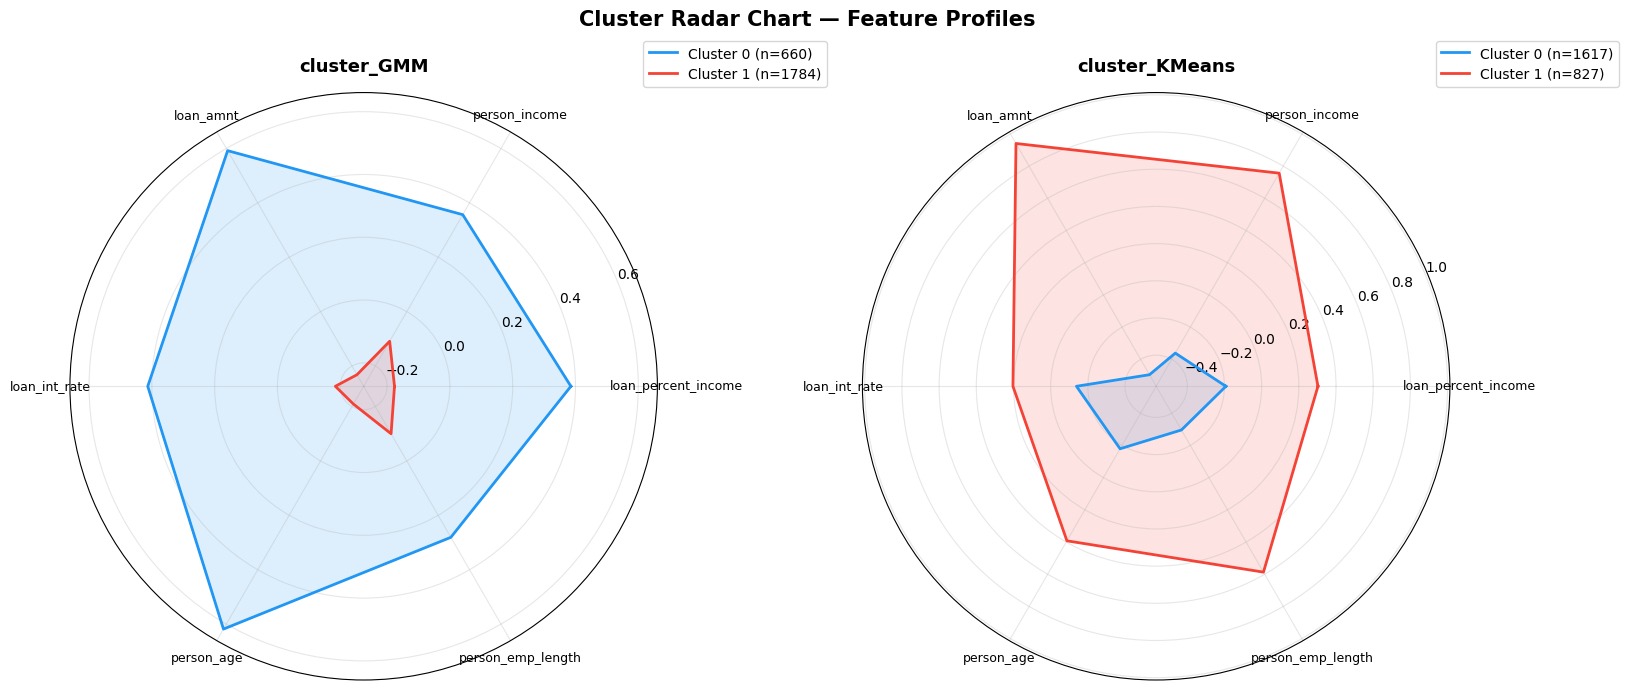

In [16]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

cluster_models = {
    "cluster_GMM":cluster_GMM,
    "cluster_KMeans":cluster_KMeans
}

# Key features for radar
radar_features = [
    'loan_percent_income',
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'person_age',
    'person_emp_length'
]

# Number of features
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, axes = plt.subplots(
    1, 2, figsize=(16, 7),
    subplot_kw=dict(polar=True))

colors = ['#2196F3', '#F44336']  # blue, red

for ax, (name, model) in zip(axes, cluster_models.items()):
    labels  = model.predict(X_val_cls)
    X_profile = X_val_cls.copy()
    X_profile['cluster'] = labels

    for cluster_id in sorted(X_profile['cluster'].unique()):
        values = X_profile[X_profile['cluster'] == cluster_id][
            radar_features].mean().tolist()
        values += values[:1]  # close the circle

        size = X_profile[X_profile['cluster'] == cluster_id].shape[0]

        ax.plot(angles, values,
                color=colors[cluster_id],
                linewidth=2,
                label=f'Cluster {cluster_id} (n={size})')
        ax.fill(angles, values,
                color=colors[cluster_id],
                alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=9)
    ax.set_title(f'{name}', fontsize=13,
                 fontweight='bold', pad=15)
    ax.legend(loc='upper right',
              bbox_to_anchor=(1.3, 1.1))
    ax.grid(True, alpha=0.3)

plt.suptitle('Cluster Radar Chart — Feature Profiles',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 10: Save SHAP Values

In [19]:
SHAP_DIR = '../models/Project_Parameter_Files/shap_values'
os.makedirs(SHAP_DIR, exist_ok=True)

# Save Classification SHAP values
np.save(f'{SHAP_DIR}/shap_values_cls.npy',
        shap_values_cls)
np.save(f'{SHAP_DIR}/shap_values_cls_default.npy',
        shap_values_cls_default)
np.save(f'{SHAP_DIR}/shap_expected_value_cls.npy',
        np.array([expected_value]))
X_shap_cls.to_csv(f'{SHAP_DIR}/X_shap_cls.csv',
                  index=False)

# Save Regression SHAP values
np.save(f'{SHAP_DIR}/shap_values_reg.npy',
        shap_values_reg)
np.save(f'{SHAP_DIR}/shap_expected_value_reg.npy',
        np.array([expected_value_reg]))
X_shap_reg.to_csv(f'{SHAP_DIR}/X_shap_reg.csv',
                  index=False)

# Save Clustering labels
for name, model in cluster_models.items():
    labels = model.predict(X_val_cls)
    np.save(f'{SHAP_DIR}/cluster_labels_{name}.npy', labels)

print(" All SHAP values and cluster labels saved")
print("\nSaved files:")
print(f"  - {SHAP_DIR}/shap_values_cls.npy")
print(f"  - {SHAP_DIR}/shap_values_cls_default.npy")
print(f"  - {SHAP_DIR}/shap_expected_value_cls.npy")
print(f"  - {SHAP_DIR}/X_shap_cls.csv")
print(f"  - {SHAP_DIR}/shap_values_reg.npy")
print(f"  - {SHAP_DIR}/shap_expected_value_reg.npy")
print(f"  - {SHAP_DIR}/X_shap_reg.csv")
print(f"  - {SHAP_DIR}/cluster_labels_cluster_GMM.npy")
print(f"  - {SHAP_DIR}/cluster_labels_cluster_KMeans.npy")


 All SHAP values and cluster labels saved

Saved files:
  - ../models/Project_Parameter_Files/shap_values/shap_values_cls.npy
  - ../models/Project_Parameter_Files/shap_values/shap_values_cls_default.npy
  - ../models/Project_Parameter_Files/shap_values/shap_expected_value_cls.npy
  - ../models/Project_Parameter_Files/shap_values/X_shap_cls.csv
  - ../models/Project_Parameter_Files/shap_values/shap_values_reg.npy
  - ../models/Project_Parameter_Files/shap_values/shap_expected_value_reg.npy
  - ../models/Project_Parameter_Files/shap_values/X_shap_reg.csv
  - ../models/Project_Parameter_Files/shap_values/cluster_labels_cluster_GMM.npy
  - ../models/Project_Parameter_Files/shap_values/cluster_labels_cluster_KMeans.npy


###  Step 11: Document Report

In [20]:
# See files in docs/model_explainability_report.md